# Single-Market Backtest — v2

A **backtest** runs a trading strategy over historical data to see what would have happened if you'd actually been pressing the buy/sell buttons in real time. It's the standard tool for validating a trading idea before risking real capital.

This notebook does an end-to-end one:

1. Picks the highest-volume Polymarket outcome in the dataset.
2. **Reconstructs OHLCV bars** — from the raw fill stream, builds a candlestick-style price/volume series at a chosen bar size (10 minutes here).
3. Runs an **SMA-crossover strategy** — a textbook trend-following rule based on two moving averages.
4. Compares strategy equity to **buy-and-hold** (just bought at the start and waited).

We deliberately avoid the heavyweight `backtrader` / `backtrader_plotting` / `bokeh` stack from the v1 notebook and run the strategy in plain numpy. The point of this notebook is to show a runnable end-to-end example, not to win a real PnL contest — the SMA crossover is a known-toy strategy that often loses to buy-and-hold in trending markets. Everything is instrumented so you can swap in your own signal.

## 1. Setup

Open DuckDB, point it at the Parquet store, and declare a `trades` view that normalises every fill into clean `notional_usdc`, `shares`, and `ctf_id` columns regardless of which side of the trade was paying USDC. From here on we can treat the data as if it was always presented in trader-friendly terms.

In [1]:
from __future__ import annotations

from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

DATA_GLOB = "../data/orderFilled/**/*.parquet"
assert any(Path("../data/orderFilled").rglob("*.parquet")), (
    "missing parquet data \u2014 run scripts/migrate_orderfilled_xz.py first"
)

con = duckdb.connect()
con.execute("SET memory_limit='6GB'")
con.execute(f"SET temp_directory='{Path('./_duckdb_tmp').resolve().as_posix()}'")

con.execute(
    f"""
    CREATE OR REPLACE VIEW raw AS
    SELECT * FROM read_parquet('{DATA_GLOB}', hive_partitioning=true)
    """
)

con.execute(
    """
    CREATE OR REPLACE VIEW trades AS
    SELECT
      to_timestamp("timestamp")::TIMESTAMP AS ts,
      year, month,
      CASE WHEN makerAssetId = '0' THEN makerAmountFilled ELSE takerAmountFilled END / 1e6 AS notional_usdc,
      CASE WHEN makerAssetId = '0' THEN takerAmountFilled ELSE makerAmountFilled END / 1e6 AS shares,
      CASE WHEN makerAssetId = '0' THEN takerAssetId ELSE makerAssetId END AS ctf_id
    FROM raw
    """
)

## 2. Pick the highest-volume market

Without the `markets` table loaded we can't look up by question text ("Will Trump win the 2024 election?") — so we rank by raw USDC volume and grab the top 20.

For each candidate we report:

- **volume** — total USDC traded in this outcome.
- **fills** — number of trades. Good proxy for liquidity / how often you'd actually be able to enter or exit at a sensible price.
- **first_ts / last_ts** — when the market opened and closed (resolved).

`RANK = 1` selects the very busiest outcome. Tweak it to backtest a different market. Once you've run `poly-data update-markets` you can join `data/markets/**/*.parquet` to recover human-readable titles.

In [2]:
RANK = 1

top = con.sql("""
    SELECT ctf_id,
           sum(notional_usdc) AS volume,
           count(*)           AS fills,
           min(ts)            AS first_ts,
           max(ts)            AS last_ts
    FROM trades
    WHERE ctf_id IS NOT NULL
    GROUP BY ctf_id
    ORDER BY volume DESC
    LIMIT 20
""").pl()

with pl.Config(fmt_str_lengths=24, tbl_rows=20):
    print(top)

TARGET_ID = top["ctf_id"][RANK - 1]
print(f"\nselected ctf_id (rank {RANK}): {TARGET_ID}")
print(f"  range: {top['first_ts'][RANK-1]} \u2192 {top['last_ts'][RANK-1]}")
print(f"  volume: ${top['volume'][RANK-1]:,.0f}  fills: {top['fills'][RANK-1]:,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

shape: (20, 5)
┌───────────────────────────┬──────────┬─────────┬─────────────────────┬─────────────────────┐
│ ctf_id                    ┆ volume   ┆ fills   ┆ first_ts            ┆ last_ts             │
│ ---                       ┆ ---      ┆ ---     ┆ ---                 ┆ ---                 │
│ str                       ┆ f64      ┆ i64     ┆ datetime[μs]        ┆ datetime[μs]        │
╞═══════════════════════════╪══════════╪═════════╪═════════════════════╪═════════════════════╡
│ 217426331434639062905690… ┆ 1.2195e9 ┆ 3450272 ┆ 2024-01-05 03:36:24 ┆ 2024-11-06 16:20:35 │
│ 692369236200776910270839… ┆ 5.7053e8 ┆ 1752210 ┆ 2024-01-05 07:10:04 ┆ 2024-11-06 19:07:20 │
│ 457148706340909084038137… ┆ 4.7064e8 ┆ 1736116 ┆ 2024-11-02 00:19:33 ┆ 2025-01-20 23:53:10 │
│ 483310433366128838909387… ┆ 4.1664e8 ┆ 1659347 ┆ 2024-01-05 03:36:24 ┆ 2024-11-06 16:20:33 │
│ 875849553592452464049521… ┆ 3.1634e8 ┆ 1060734 ┆ 2024-01-05 07:31:48 ┆ 2024-11-06 19:07:20 │
│ 343795817898955285602812… ┆ 1.701

## 3. Reconstruct OHLCV bars

Real markets quote one price per fill, but most strategies and chart tools want **bars** — fixed time windows summarised into five numbers, the classic OHLCV:

- **O**pen — first traded price in the bar.
- **H**igh — highest price in the bar.
- **L**ow — lowest price in the bar.
- **C**lose — last traded price in the bar.
- **V**olume — total USDC traded during the bar.

These are exactly the four values that draw a candlestick on a chart, plus volume on a bottom panel. We choose **10-minute bars**: short enough to catch intraday moves, long enough to be statistically meaningful. We then clip to roughly the last 6 months of activity to keep the chart readable and focus on the period when the market actually had volume.

Bars without any fill are dropped (`dropna`) — there's no price to record.

In [3]:
ticks = con.sql(f"""
    SELECT ts,
           notional_usdc / shares AS price,
           notional_usdc          AS volume
    FROM trades
    WHERE ctf_id = '{TARGET_ID}'
      AND shares > 0
      AND notional_usdc > 0
    ORDER BY ts
""").pl()
print(f"raw ticks: {ticks.height:,}")

ticks_pd = ticks.to_pandas().set_index("ts")
ohlcv = ticks_pd.resample("10min").agg(
    open=("price", "first"),
    high=("price", "max"),
    low=("price", "min"),
    close=("price", "last"),
    volume=("volume", "sum"),
).dropna()

# clip to roughly the last 6 months of activity
tail_start = ohlcv.index.max() - pd.Timedelta(days=180)
ohlcv = ohlcv.loc[ohlcv.index >= tail_start].copy()
print(f"OHLCV bars: {len(ohlcv):,}  range {ohlcv.index.min()} \u2192 {ohlcv.index.max()}")

ohlcv.head()

raw ticks: 3,450,272


OHLCV bars: 21,882  range 2024-05-10 18:20:00 → 2024-11-06 16:20:00


,open,high,low,close,volume
ts,,,,,
2024-05-10 18:20:00,0.45,0.45,0.45,0.45,39.999998
2024-05-10 18:50:00,0.45,0.45,0.45,0.45,6.199998
2024-05-10 19:30:00,0.45,0.45,0.45,0.45,19.999998
2024-05-10 19:40:00,0.45,0.45,0.45,0.45,9.999998
2024-05-10 22:20:00,0.45,0.45,0.45,0.45,984.339998


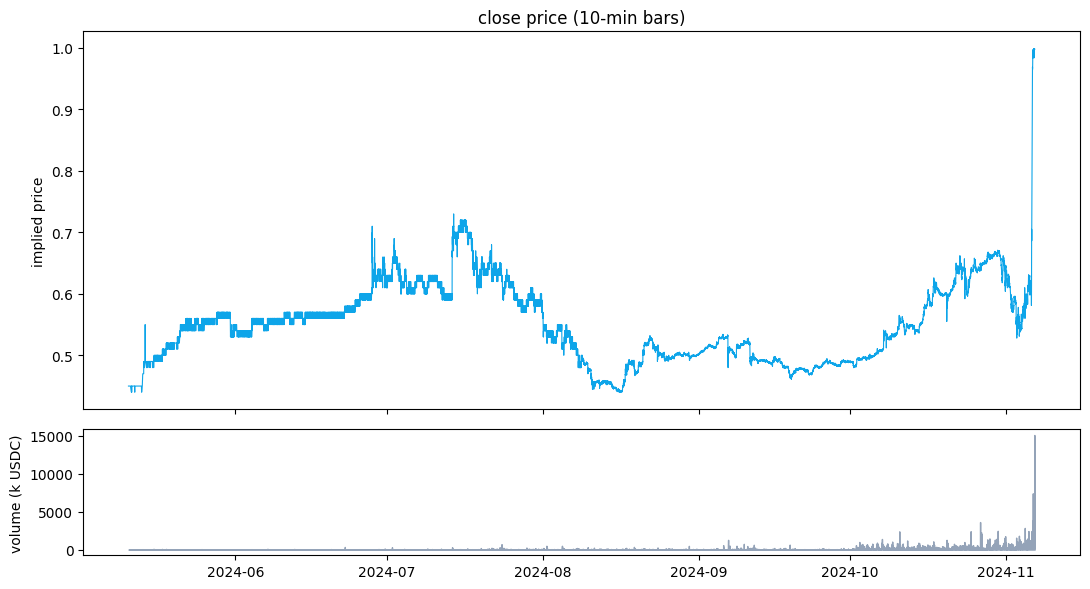

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1]})
axes[0].plot(ohlcv.index, ohlcv["close"], color="#0ea5e9", lw=0.8)
axes[0].set_ylabel("implied price")
axes[0].set_title("close price (10-min bars)")
axes[1].fill_between(ohlcv.index, 0, ohlcv["volume"] / 1e3, color="#94a3b8")
axes[1].set_ylabel("volume (k USDC)")
plt.tight_layout()
plt.show()

## 4. SMA-crossover strategy

A **Simple Moving Average (SMA)** is the average closing price over the last *N* bars; it smooths out short-term noise and reveals the underlying trend. The classic crossover rule:

- Compute a **fast** SMA (here 50 bars ≈ 8 hours) and a **slow** SMA (here 200 bars ≈ 33 hours).
- When the **fast crosses above the slow** ("golden cross"), the trend is turning up → **go long** (buy).
- When the **fast crosses below the slow** ("death cross"), the trend is turning down → **go flat** (sell everything).

Additional rules baked in:

- **Stop-loss at 2%** — if price drops 2% below your entry, exit immediately even if the SMAs haven't crossed yet. Caps each losing trade.
- **No leverage, no shorting** — Polymarket can't short anyway (you can't owe outcome shares you don't have).
- **95% of cash deployed each entry** — keeps a tiny buffer for fees / rounding.
- **Vectorised** — we precompute signals for the whole series with pandas, then walk through bars updating cash + share state. Much faster than a per-tick event loop.

Output:

- **strategy final equity** — what $10,000 became running this rule from start to end.
- **buy-and-hold** — what $10,000 became just buying at bar 1 and holding to the end. The reference benchmark — the strategy has to beat this to be "worth it."
- **trades executed** — round-trip count. Lots of trades in real life means lots of slippage and fees (which we're ignoring here).

Each row in `trade_log` is one buy or sell with the **reason**: `cross_up` (fast SMA crossed above slow), `cross_down` (fast crossed below slow), `stop` (stop-loss tripped), or `final_unwind` (we sold whatever was left at the very last bar so the comparison is apples-to-apples).

In [5]:
FAST = 50
SLOW = 200
STOP_LOSS = 0.02   # 2%
RISK = 0.95        # fraction of cash deployed
STARTING_CASH = 10_000.0
FEE = 0.0          # Polymarket native fees ~0%

df = ohlcv.copy()
df["fast"] = df["close"].rolling(FAST).mean()
df["slow"] = df["close"].rolling(SLOW).mean()
df["signal"] = (df["fast"] > df["slow"]).astype(int)
df["signal_prev"] = df["signal"].shift(1).fillna(0)
df = df.dropna(subset=["fast", "slow"]).copy()

cash = STARTING_CASH
shares = 0.0
entry_price: float | None = None

equity = []
trades = []

for ts, row in df.iterrows():
    px = row["close"]
    crossed_up   = row["signal"] == 1 and row["signal_prev"] == 0
    crossed_down = row["signal"] == 0 and row["signal_prev"] == 1
    stop_hit = (entry_price is not None) and (px <= entry_price * (1 - STOP_LOSS))

    if shares > 0 and (crossed_down or stop_hit):
        cash += shares * px * (1 - FEE)
        trades.append((ts, "SELL", px, shares, cash, "stop" if stop_hit else "cross_down"))
        shares = 0.0
        entry_price = None

    if shares == 0 and crossed_up:
        notional = cash * RISK
        size = notional / px
        cash -= notional * (1 + FEE)
        shares = size
        entry_price = px
        trades.append((ts, "BUY", px, size, cash, "cross_up"))

    equity.append((ts, cash + shares * px))

if shares > 0:
    last_px = df["close"].iloc[-1]
    cash += shares * last_px * (1 - FEE)
    trades.append((df.index[-1], "SELL", last_px, shares, cash, "final_unwind"))
    shares = 0.0

equity_df = pd.DataFrame(equity, columns=["ts", "equity"]).set_index("ts")
trade_log = pd.DataFrame(trades, columns=["ts", "action", "price", "size", "cash_after", "reason"])

final = equity_df["equity"].iloc[-1]
buyhold = STARTING_CASH * (df["close"].iloc[-1] / df["close"].iloc[0])
print(f"strategy final equity: ${final:,.2f}  ({(final/STARTING_CASH - 1):+.2%})")
print(f"buy-and-hold:          ${buyhold:,.2f}  ({(buyhold/STARTING_CASH - 1):+.2%})")
print(f"trades executed:       {len(trade_log)}")
trade_log.head(10)

strategy final equity: $11,834.03  (+18.34%)
buy-and-hold:          $19,960.00  (+99.60%)
trades executed:       152


,ts,action,price,size,cash_after,reason
0,2024-05-16 10:50:00,BUY,0.500000,19000.000000,500.000000,cross_up
1,2024-05-16 11:20:00,SELL,0.490000,19000.000000,9810.000000,stop
2,2024-05-24 07:10:00,BUY,0.560000,16641.964286,490.500000,cross_up
3,2024-05-24 15:50:00,SELL,0.540000,16641.964286,9477.161388,stop
4,2024-05-25 12:40:00,BUY,0.560000,16077.327538,473.858069,cross_up
5,2024-05-25 13:40:00,SELL,0.540000,16077.327538,9155.614940,stop
6,2024-05-25 14:00:00,BUY,0.560000,15531.846773,457.780747,cross_up
7,2024-05-25 14:40:00,SELL,0.540000,15531.846773,8844.978004,stop
8,2024-05-28 08:10:00,BUY,0.570000,14741.630199,442.248900,cross_up
9,2024-05-30 07:50:00,SELL,0.569979,14741.630199,8844.667162,cross_down


## 5. Visualise

Two stacked panels:

- **Top** — close price (grey), fast SMA (blue), slow SMA (red), with green ▲ markers for buys and red ▼ markers for sells. Visually you can see the strategy entering after each upcrossing of the SMAs and exiting on either downcrossing or stop-loss.
- **Bottom** — equity curve of the strategy (blue) vs. **buy-and-hold** (grey dashed). The horizontal line at the starting cash level lets you read drawdowns at a glance. If the blue line spends most of its time below the dashed line, the strategy is underperforming the trivial buy-and-hold benchmark.

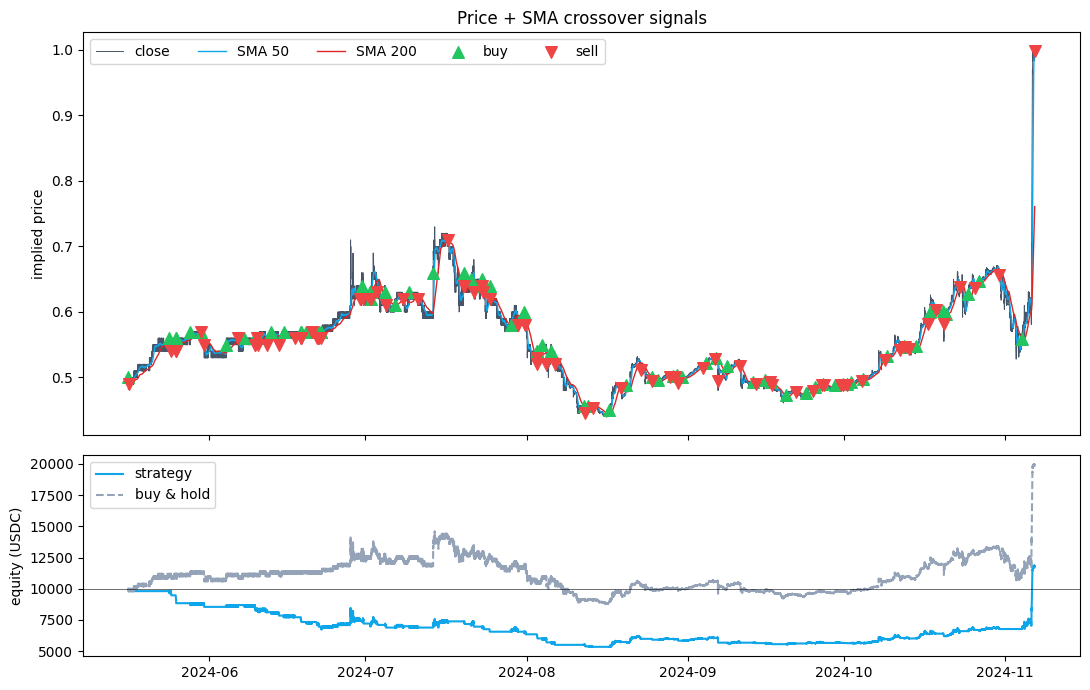

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                          gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(df.index, df["close"], color="#475569", lw=0.7, label="close")
axes[0].plot(df.index, df["fast"], color="#0ea5e9", lw=1.0, label=f"SMA {FAST}")
axes[0].plot(df.index, df["slow"], color="#dc2626", lw=1.0, label=f"SMA {SLOW}")
buys = trade_log[trade_log["action"] == "BUY"]
sells = trade_log[trade_log["action"] == "SELL"]
axes[0].scatter(buys["ts"],  buys["price"],  marker="^", color="#22c55e", s=70, zorder=5, label="buy")
axes[0].scatter(sells["ts"], sells["price"], marker="v", color="#ef4444", s=70, zorder=5, label="sell")
axes[0].set_ylabel("implied price")
axes[0].set_title("Price + SMA crossover signals")
axes[0].legend(loc="best", ncols=5)

axes[1].plot(equity_df.index, equity_df["equity"], color="#0ea5e9", label="strategy")
buyhold_curve = STARTING_CASH * (df["close"] / df["close"].iloc[0])
axes[1].plot(df.index, buyhold_curve, color="#94a3b8", ls="--", label="buy & hold")
axes[1].axhline(STARTING_CASH, color="black", lw=0.4)
axes[1].set_ylabel("equity (USDC)")
axes[1].legend()
plt.tight_layout()
plt.show()

## Notes

- **YES vs. NO:** the CTF token id has two outcomes per binary market (a YES side and a NO side). The price you see here is for whichever outcome ends up in `ctf_id` after the maker/taker normalisation. To pin a specific outcome, join `ctf_id` against the `markets` table to identify token1/token2 (for example, "Trump wins" vs. "Trump loses").
- **Backtest is intentionally simplistic:** no slippage modelling, no maker/taker fee asymmetry, no funding lock. Real Polymarket backtests should subtract the *bid-ask spread* (the gap between the best buy order and best sell order in the book — the implicit cost of crossing it) at each fill. Without an L2 (level-2 order-book) snapshot you can approximate it by widening fills by a configurable bps ("basis points" — hundredths of a percent).
- **Performance:** for larger studies, push the strategy loop into Polars or numba — the pandas iterrows above is fine for one market over a few thousand bars but quickly chokes on cross-sectional sweeps over hundreds of markets.